Primary Research Question: Does the network exhibit scale-free properties (i.e., does the degree distribution follow a power law)?

We are basing this on the Clauset, Shalizi, and Newman's (2009) seminal paper, 'Power-Law Distributions in Empirical Data', for testing power law distributions in real-world data. More specifically, we are using the Kolmogorov-Smirnov test to assess how well the power law actually fits. 

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import powerlaw
from matplotlib.ticker import FuncFormatter

Read in the data:

In [45]:
# Load CSV with node degree attributes
df = pd.read_csv('data/node_degree_attributes.csv', encoding='utf-8')

# Extract degree values
degree_sequence = df['Degree'].values

First, explore the data with a basic histogram. We are looking for a heavy tail.

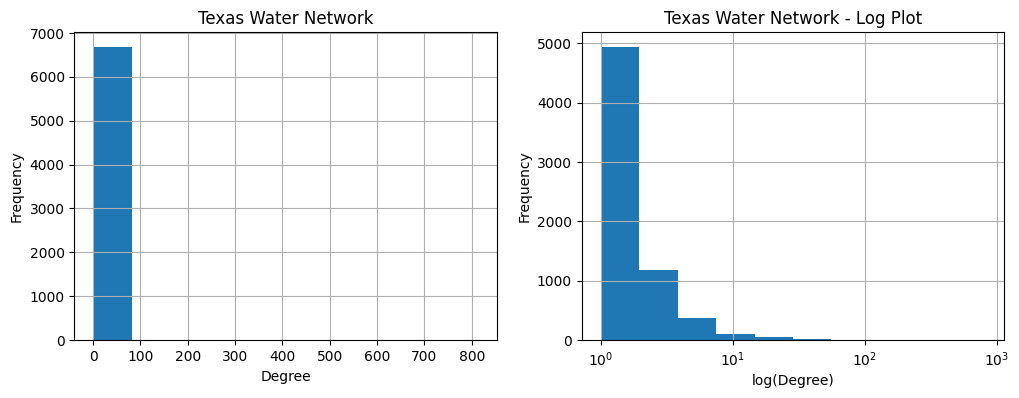

In [88]:
def plot_histograms(data, title, var_name):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(data)
    plt.title(title)
    plt.xlabel(var_name)
    plt.ylabel("Frequency")
    plt.grid()
    
    plt.subplot(1,2,2)
    plt.hist(np.log10(data))
    plt.title(title + " - Log Plot")
    plt.xlabel("log(" + var_name + ")")
    plt.ylabel("Frequency")
    plt.grid()
    plt.gca().xaxis.set_major_locator(plt.MultipleLocator(1))  
    plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'10$^{{{int(x)}}}$'))

plot_histograms(degree_sequence, "Texas Water Network", "Degree")

Take a look at the data using the basic log-log plot, this is a quick way to visually "guess-timate" is the data follows a power law. That is, we should easily spot a heavy tail. This is **only** a useful tool for data exploration as it does not test if the data fit a power law distribution. 

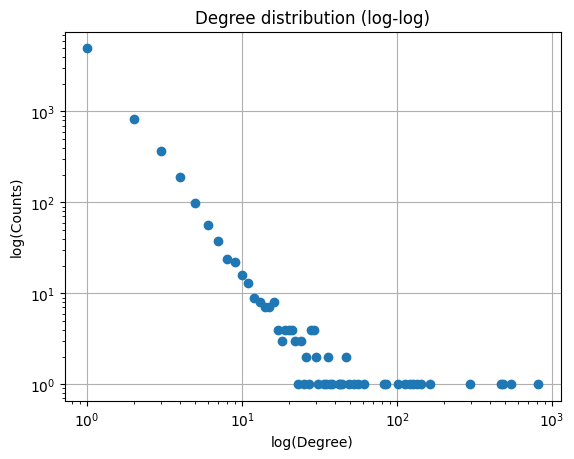

In [72]:
def plot_loglog_distribution(data: np.ndarray, title: str, var_name: str) :
    # Pull unique values for degrees and counts
    unique_degs, counts = np.unique(degree_sequence, return_counts=True)
    
    # Plot the distiribution
    plt.figure()
    plt.loglog(unique_degs, counts, marker='o', linestyle='None')    
    plt.xlabel(f"log({var_name})")
    plt.ylabel(f'log(Counts)')
    plt.title('Degree distribution (log-log)')
    plt.grid()

plot_loglog_distribution(degree_sequence, 'Degree Distribution (log-log)', 'Degree')

The log-log plot actually is pretty helpful in visually identifying potential power law scaling. The heavy tail distribution suggests the pressence of hub nodes that domminate the network. However, it is not a perfect fit. That is, the curve flattens suggesting an exponential cuttoff. That is, the network stops following the power law, this could be for a range of reasons (e.g., physical constraints).

The next step would be to plot a probability density function, which shows our data (empirital line) against a theoretial power law model. While this is still a visual assessment, it is helpful in making some high-level assessments:

- Lines overlap well at lower degrees but this agreement falls appart at higher degree values. This is consistent with what we saw with the log-log plot.
- This plot provides additional evidence that this network is "scale-free-ish" but with realistic constraints, which is typical for most real-world complex networks.

Calculating best minimal value for power law fit


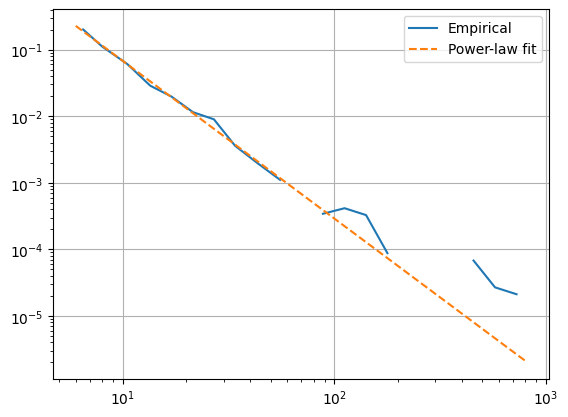

In [87]:
def plot_pdf(data: np.ndarray):
    # Fit data to power law
    fit = powerlaw.Fit(data)
    # Plot PDF
    fig = fit.plot_pdf(label='Empirical')
    fit.power_law.plot_pdf(label='Power-law fit', linestyle='--', ax=fig)
    plt.legend()
    plt.grid()

plot_pdf(degree_sequence)


Next, perform a goodness-of-fit test to determine if your data actually follows a power law distribution.

In [89]:
def compute_power_law_p_val(results):
    """
        Function to compute power law test p value as described in arXiv:0706.1062 [physics.data-an]

        Authors use rule of thumb significance threshold of p>=0.1

        Note: the larger the p value the more plausible a power law fit
    """

    return sum(results.Ds > results.D)/len(results.Ds)


# fit power to power law data
results = powerlaw.Fit(degree_sequence)
print("alpha = " + str(results.power_law.alpha)) # note: powerlaw lib's alpha definition is different than standard i.e. a_powerlawlib = a_standard + 1
print("x_min = " + str(results.power_law.xmin))
print('p = ' + str(compute_power_law_p_val(results)))



Calculating best minimal value for power law fit
alpha = 2.3682998801926196
x_min = 6.0
p = 0.9824561403508771


In [90]:
def compare_distribution_fits(results):
    """
        Function to compare power law fit to other distribution candidates

        Note:
        R = Loglikelihood ratio of the two distributions’ fit to the data. If greater than 0, the first distribution is preferred. 
        If less than 0, the second distribution is preferred.

        p = Significance of R
    """

    distribution_list = ['lognormal', 'exponential', 'truncated_power_law', 'stretched_exponential', 'lognormal_positive']
    
    for distribution in distribution_list:
        R, p = results.distribution_compare('power_law', distribution)
        print("power law vs " + distribution + ": R = " + str(np.round(R,3)) + ", p = " + str(np.round(p,3)))

# Extract degree values
degree_sequence = df['Degree'].values

# Reusing the degree_sequence from above
fit = powerlaw.Fit(degree_sequence)

# Compare distribution fits:
compare_distribution_fits(fit)


Calculating best minimal value for power law fit
power law vs lognormal: R = -0.759, p = 0.209
power law vs exponential: R = 213.15, p = 0.0
power law vs truncated_power_law: R = 0.0, p = 0.999
power law vs stretched_exponential: R = 5.024, p = 0.003
power law vs lognormal_positive: R = 16.489, p = 0.0


/Users/chris/Desktop/twn-first-paper/venv/lib/python3.11/site-packages/powerlaw.py:1615: RuntimeWarning: invalid value encountered in divide
  CDF = CDF/norm
'nan' in fit cumulative distribution values.
Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.
Assuming nested distributions


## Parking Lot of Ideas

In [91]:
# Null hypothesis test for scale-free network
# H0: The degree distribution follows a power-law
# H1: The degree distribution does not follow a power-law

#Reusing the degree_sequence from above
fit = powerlaw.Fit(degree_sequence)

#KS statistic (distance between the distribution and the data)
ks_statistic= fit.power_law.KS()

# p-value comes from the fit object as well
p_value= fit.power_law.D #fit stores KS distance as D

print("KS Test results:")
print(f"KS statistic (D)= {ks_statistic:.4f}")
print(f"p-value= {fit.distribution_compare('power_law','exponential')[1]:.4f}")

Calculating best minimal value for power law fit
KS Test results:8%
KS statistic (D)= 0.0224
p-value= 0.0000


In [93]:
fit.power_law.KS() 

np.float64(0.022429579617434192)